In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\customer_churn_messy_1500_rows.csv")

df.head()

,Customer_ID,Age,Gender,Income,Total_Purchases,Avg_Purchase_Value,Tenure_Months,Churn
0,5001,65.0,Female,127760.0,14.0,5295.0,28,0
1,5002,22.0,Male,78970.0,74.0,1419.0,23,0
2,5003,43.0,Female,129563.0,27.0,6969.0,29,0
3,5004,21.0,Female,59803.0,23.0,2233.0,49,0
4,5005,37.0,Male,66505.0,4.0,884.0,24,1


In [20]:
df

,Customer_ID,Age,Gender,Income,Total_Purchases,Avg_Purchase_Value,Tenure_Months,Churn
0,5001,65.0,Female,127760.0,14.0,5295.0,28,0
1,5002,22.0,Male,78970.0,74.0,1419.0,23,0
2,5003,43.0,Female,129563.0,27.0,6969.0,29,0
3,5004,21.0,Female,59803.0,23.0,2233.0,49,0
4,5005,37.0,Male,66505.0,4.0,884.0,24,1
...,...,...,...,...,...,...,...,...
1495,6496,22.0,Male,50846.0,NaN,3114.0,25,0
1496,6497,34.0,Female,146661.0,20.0,1993.0,11,0
1497,6498,20.0,Female,148573.0,50.0,5626.0,3,0
1498,6499,23.0,Male,93853.0,43.0,2307.0,51,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1500 non-null   int64  
 1   Age                 1500 non-null   float64
 2   Gender              1500 non-null   object 
 3   Income              1500 non-null   float64
 4   Total_Purchases     1500 non-null   float64
 5   Avg_Purchase_Value  1500 non-null   float64
 6   Tenure_Months       1500 non-null   int64  
 7   Churn               1500 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 93.9+ KB


In [36]:
df.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Income                0
Total_Purchases       0
Avg_Purchase_Value    0
Tenure_Months         0
Churn                 0
dtype: int64

In [18]:
age_mean = df["Age"].mean()
print("Mean Age:", age_mean)




Mean Age: 43.434814814814814


In [ ]:
df["Age"].fillna(df["Age"].median(), inplace=True)


In [26]:
df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)

In [30]:
df["Income"].fillna(df["Income"].mean(),inplace=True)

In [32]:
df["Total_Purchases"].fillna(df["Total_Purchases"].mean(),inplace=True)

In [34]:
df["Avg_Purchase_Value"].fillna(df["Avg_Purchase_Value"].mean(),inplace=True)

(array([ 88.,  82.,  46.,  76.,  50.,  77.,  52.,  71.,  69., 217.,  75.,
         52.,  83.,  42.,  69.,  53.,  82.,  49., 103.,  64.]),
 array([18.  , 20.55, 23.1 , 25.65, 28.2 , 30.75, 33.3 , 35.85, 38.4 ,
        40.95, 43.5 , 46.05, 48.6 , 51.15, 53.7 , 56.25, 58.8 , 61.35,
        63.9 , 66.45, 69.  ]),
 <BarContainer object of 20 artists>)

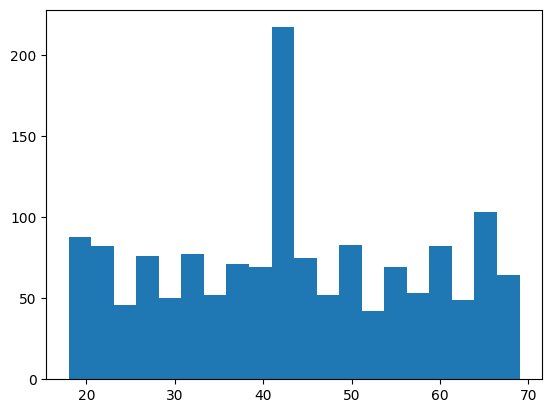

In [45]:
plt.hist(df["Age"],bins=20)
# plt.show()

(array([ 69.,  66.,  67.,  81.,  69.,  67.,  59.,  64.,  58., 225.,  72.,
         85.,  69.,  60.,  59.,  56.,  72.,  72.,  60.,  70.]),
 array([ 20010. ,  26492.9,  32975.8,  39458.7,  45941.6,  52424.5,
         58907.4,  65390.3,  71873.2,  78356.1,  84839. ,  91321.9,
         97804.8, 104287.7, 110770.6, 117253.5, 123736.4, 130219.3,
        136702.2, 143185.1, 149668. ]),
 <BarContainer object of 20 artists>)

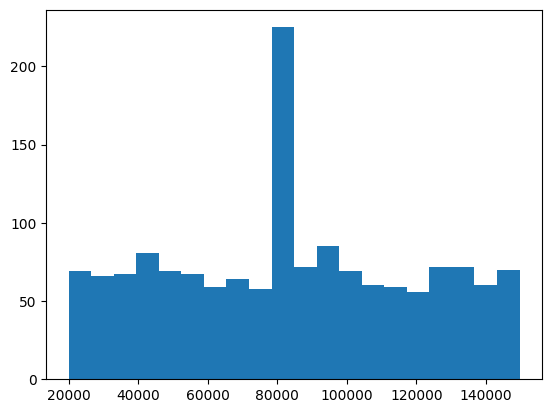

In [46]:
plt.hist(df["Income"],bins=20)

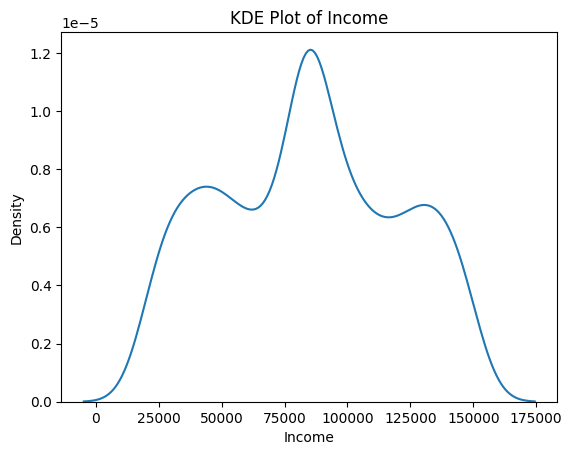

In [48]:
sns.kdeplot(df["Income"])
plt.xlabel("Income")
plt.ylabel("Density")
plt.title("KDE Plot of Income")
plt.show()


<Axes: xlabel='Total_Purchases', ylabel='Count'>

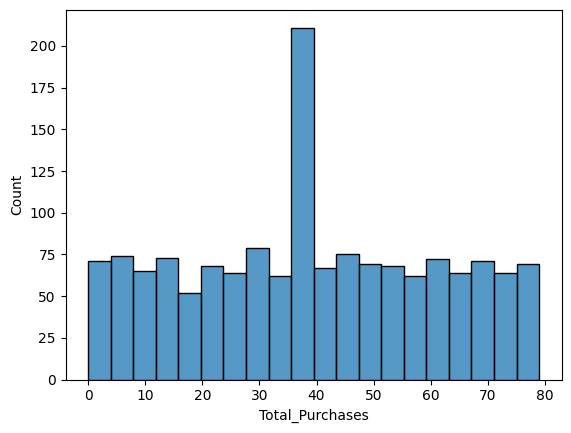

In [49]:
sns.histplot(df["Total_Purchases"],bins=20)

<Axes: xlabel='Gender', ylabel='Total_Purchases'>

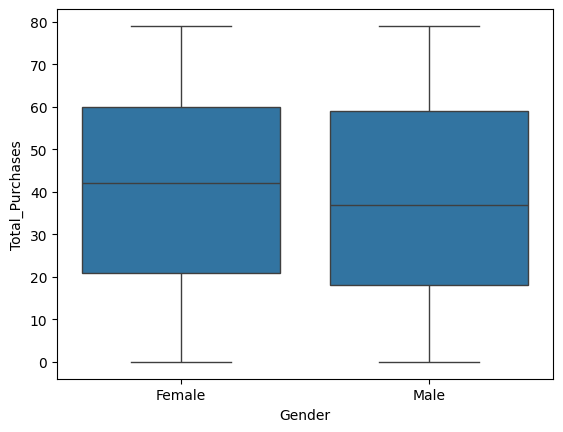

In [55]:
sns.boxplot(x=df["Gender"] ,y=df["Total_Purchases"],data=df)

<Axes: xlabel='Income', ylabel='Churn'>

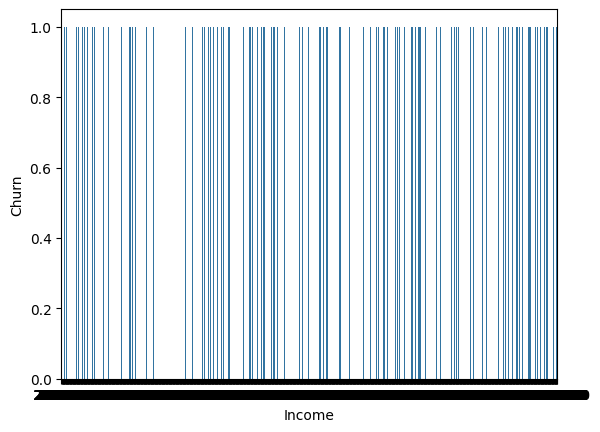

In [64]:
sns.barplot(x=df["Income"],y=df["Churn"])

<Axes: >

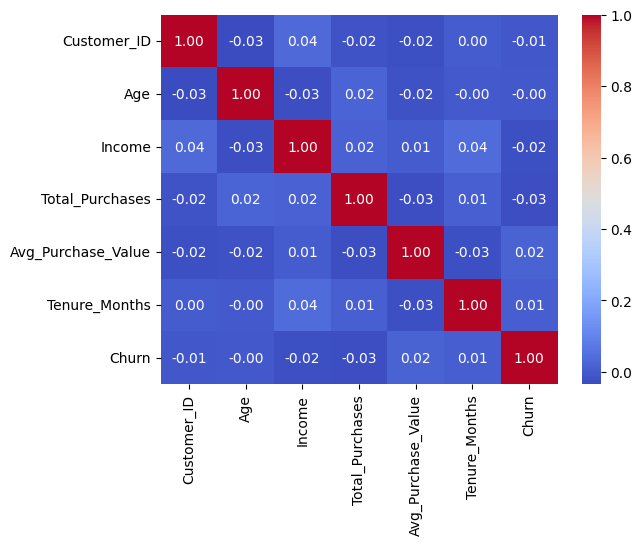

In [67]:
num_df = df.select_dtypes(include=["int64", "float64"])
corr = num_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")


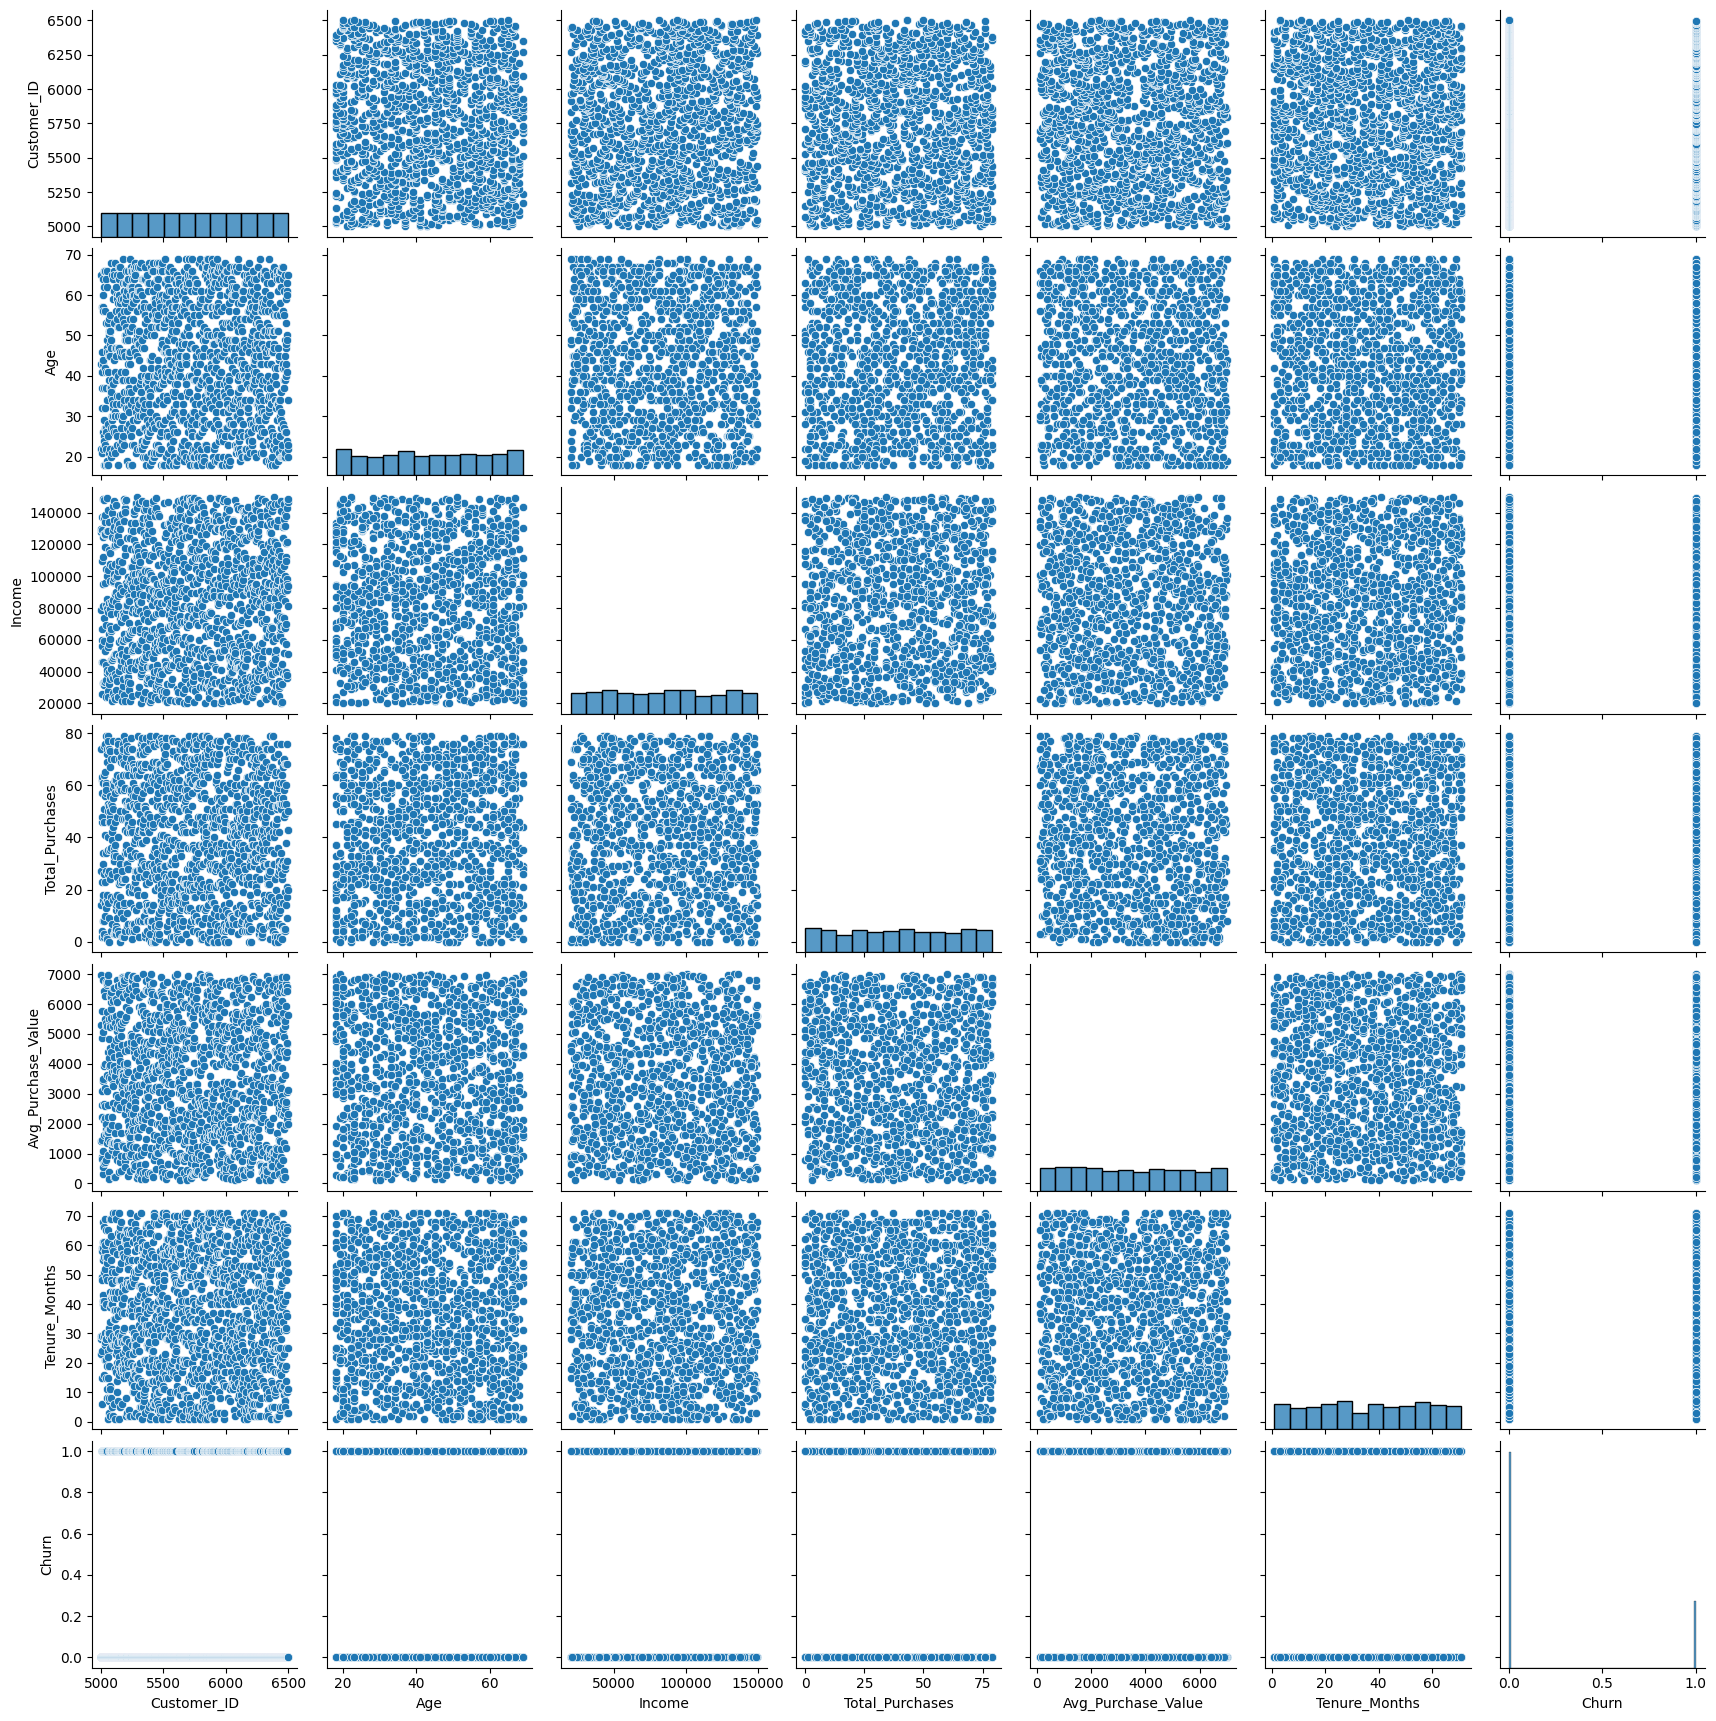

In [68]:
sns.pairplot(num_df)